In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключаем метод norm
from scipy.stats import norm

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей ансамбль
# координат случайных блужданий

# инициализация генератора случайных чисел
random.seed()


# задание функции,
# реализующей метод Монте-Карло
def Walk(N_step, N_trial, p):
    # N_step - число шагов
    #          броуновской частицы
    # N_trial - количество генерируемых траекторий

    # инициализация массива,
    # используемого для размещения
    # генерируемых значений
    z = np.zeros(N_trial)

    # метод Монте-Карло
    for i in range(2, N_trial):
        x = 0
        for j in range(N_step):
            if p >= random.uniform(0, 1):
                x = x + 1
            else:
                x = x - 1
        z[i] = x

    return z


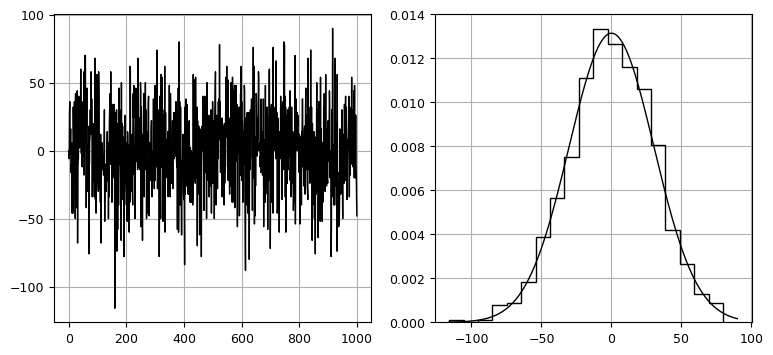

In [3]:
# Ячейка № 3

# вычисление и визуализация
# мгновенных координат
# траектории случайных блужданий
# и соответствующих значений
# плотности распределения

# задание значения числа
# шагов броуновской частицы
N_step = 10**3

# задание значения
# числа независимых испытаний
# в методе Монте-Карло
N_trial = 10**3

# задание порогового
# вероятности совершения
# броуновской частицей шага вправо
p = 0.5

# вычисление значений координат
# случайных блужданий на
# шаге с номером N_step
M = Walk(N_step, N_trial, p)

# задание значений интервалов гистограммы
N_bin = 20  # np.max(M) - np.min(M)
xbins = np.arange(np.min(M), np.max(M), (np.max(M) - np.min(M)) / N_bin)

# вычисление среднего значения
# ансамбля координат случайных
# блужданий
M_mean = np.mean(M)

# вычисляем дисперсию
# ансамбля координат случайных
# блужданий
M_std = np.std(M)


# вычисление значения плотности
# нормального распределения
# N(M_mean,M_std)
x = np.arange(np.min(M), np.max(M), 0.1)
dP_est = norm.pdf(x, M_mean, M_std)

# визуализация сгенерированной
# случайной последовательности,
# ее гистограммы и плотности
# распределения
fig = plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
# визуализация ансамбля
# координат случайных
# блужданий
plt.plot(M, "-k", lw=1)
# plt.ylim([0,0.05])
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация гистограммы
# ансамбля координат
# случайных блужданий
plt.hist(M, bins=xbins, histtype="step", color="black", density=True)

# визуализация плотности
# плотности нормального
# распределения N(M_mean,M_std)
plt.plot(x, dP_est, "-k", lw=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True)

plt.show()

In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# координаты траектории
# броуновской частицы,
# и соответствующие значения
# плотности вероятности
def Distr(M):
    # М - массив, содержащий
    # мгновенные значения
    # координат траектории
    # броуновской частицы

    # задание функции, преобразующей
    # элементы массива float
    # в массив int
    def f(x):
        return int(x)

    f2 = np.vectorize(f)

    # преобразование массива
    # M типа float
    # в массив M_int
    # типа Int
    M_int = f2(M)

    # определение минимального и
    # максимального значений координат
    # броуновской частицы
    M_min = int(np.min(M_int))
    M_max = int(np.max(M_int))

    # инициализация массива S,
    # используемого для хранения
    # координат траектории
    # броуновской частицы и
    # соответствующих значений
    # плотностей вероятностей
    S = np.zeros([M_max - M_min, 2])

    # вычисление
    # плотности вероятностей
    # нахождения броуновской частицы
    # в каждой точке ее траектории
    k = M_min
    K = 0
    for k in range(M_min, M_max):
        n = 0
        for i in range(len(M)):
            if k == int(M[i]):
                n = n + 1
        if K == 0:
            S[0, 0] = k
            S[0, 1] = n / len(M)
        else:
            S[K, 0] = k
            S[K, 1] = n / len(M)
        K = K + 1
    return S

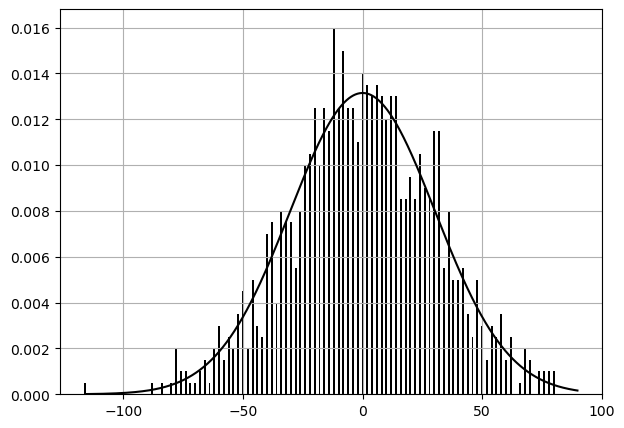

In [5]:
# Ячейка № 5

# вычисление координат
# траектории броуновской частицы
# и соответствующих плотностей
# в данной точке
S = Distr(M)

# визуализация плотности распределения
# случайной последовательности
fig = plt.figure(figsize=(7, 5))
plt.bar(S[:, 0], S[:, 1] / 2, color="black")
# визуализация плотности
# плотности нормального
# распределения N(M_mean,M_std) * (xbins[1]-xbins[0])
plt.plot(x, dP_est, color="black")
plt.grid(True)

plt.show()